## Actividad 1 - Clase 4
#### Alumno: Enzo Melian

El objetivo de esta actividad es encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la
regresión lineal para intentar predecirla a partir de las demás variables predictoras.
El método que seguiremos es el siguiente:
● Preparación y organización de datos
● Exploración de los datos
● Modelado de datos

En mi caso elegi un dataset sobre el consumo de combustible en autos, y cuanto co2 estos mismos emiten. 

In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import linear_model, model_selection
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, explained_variance_score,
    confusion_matrix, accuracy_score, classification_report
    )

df = pd.read_csv('co2_mini.csv', encoding='ISO-8859-1')
df

,consumption,co2
0,8.5,196
1,9.6,221
2,5.9,136
3,11.1,255
4,10.6,244
...,...,...
3197,9.4,219
3198,9.9,232
3199,10.3,240
3200,9.9,232


Descripción estadística:
       consumption          co2
count  3202.000000  3202.000000
mean     11.422767   266.043410
std       2.436661    56.695972
min       5.300000   122.000000
25%       9.600000   225.000000
50%      11.000000   255.000000
75%      12.900000   301.000000
max      22.200000   522.000000


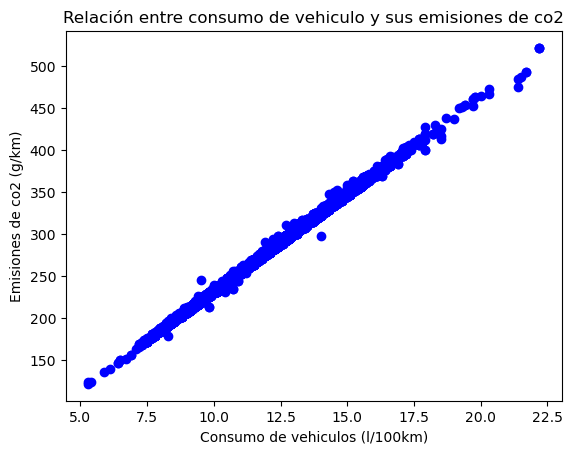

In [23]:
print("Descripción estadística:")
print(df.describe())

plt.scatter(df['consumption'], df['co2'], color='blue')
plt.xlabel("Consumo de vehiculos (l/100km)")
plt.ylabel("Emisiones de co2 (g/km)")
plt.title("Relación entre consumo de vehiculo y sus emisiones de co2")
plt.show()

In [24]:
X = df[['consumption']]
y = df['co2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

Intercepto: 0.6854997515185346
Coeficiente: [23.23018439]

Evaluación del modelo (Regresión Simple):
MAE: 2.3198134868503244
MSE: 8.059048462494841
R²: 0.9975345166663068
Varianza explicada: 0.9975347019443137


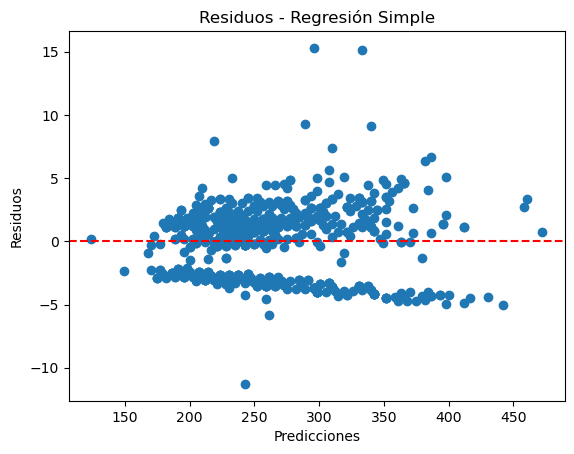

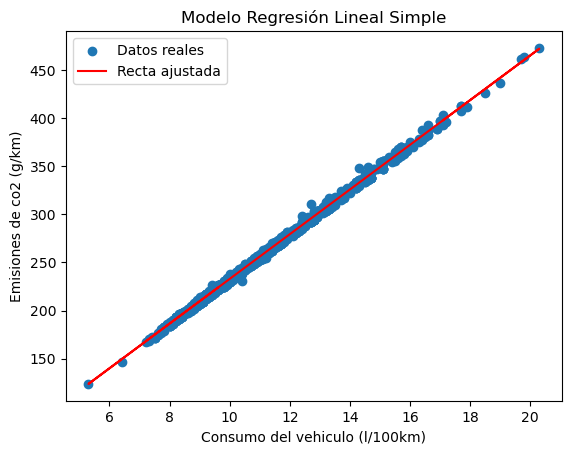

In [25]:
print("Intercepto:", model_simple.intercept_)
print("Coeficiente:", model_simple.coef_)

print("\nEvaluación del modelo (Regresión Simple):")
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("MSE:", mean_squared_error(y_test, y_pred_simple))
print("R²:", r2_score(y_test, y_pred_simple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_simple))

residuos = y_test - y_pred_simple
plt.scatter(y_pred_simple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Simple")
plt.show()

plt.scatter(X_test, y_test, label="Datos reales")
plt.plot(X_test, y_pred_simple, color='red', label="Recta ajustada")
plt.xlabel("Consumo del vehiculo (l/100km)")
plt.ylabel("Emisiones de co2 (g/km)")
plt.legend()
plt.title("Modelo Regresión Lineal Simple")
plt.show()

----- 

## Actividad 2 

Para esta actividad se ha creado un archivo usuarios_win_mac_lin.csv con datos de entrada a modo de ejemplo para clasificar si el usuario que
visita un sitio web usa como sistema operativo Windows, Macintosh o Linux.
Nuestra información de entrada son 4 características que se tomó de una web que utiliza Google Analytics y son:

Valores a las etiquetas:
- 0 – Windows
- 1 – Macintosh
- 2 -Linux

Tu tarea es crear una Jupyter Notebook Regresion_logistica.ipynb que permita predecir qué sistema operativo utiliza un usuario según los datos
de entrada.

In [26]:
df_2 = pd.read_csv('usuarios_win_mac_lin.csv', encoding='ISO-8859-1')
df_2

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2
...,...,...,...,...,...
165,13.0,1,7,42,0
166,12.0,1,2,6,0
167,13.0,1,3,9,0
168,13.0,1,7,28,0


Precisión Global (Accuracy): 0.68

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



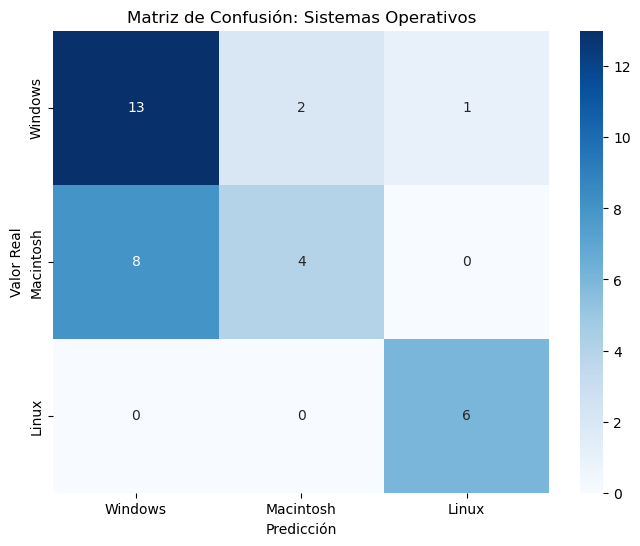

In [28]:
# Preparación de características (X) y etiquetas (y)
# Las características son: duración, páginas, acciones, valor
X = df_2.drop('clase', axis=1)
y = df_2['clase']

# Divido el dataset (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de Regresión Logística
# max_iter se aumenta para asegurar la convergencia del algoritmo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluación del modelo
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Visualización de resultados (Matriz de Confusión)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Windows', 'Macintosh', 'Linux'], 
            yticklabels=['Windows', 'Macintosh', 'Linux'])
plt.title('Matriz de Confusión: Sistemas Operativos')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
